<a href="https://www.kaggle.com/code/diptinagvekar/skin-lesion-classification-cnn-transfer-learning?scriptVersionId=311734841" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

## Problem Statement

To build a multiclass deep learning model that can 
accurately detect melanoma and other skin lesions from 
dermatoscopic images.
Melanoma is a type of cancer that can be deadly if not detected early. It accounts 
for 75% of skin cancer deaths despite being one of the 
least common skin cancers.

### Importing necessary libraries:

In [1]:
# Installing Augmentor library for data augmentation to handle class imbalance.
!pip install Augmentor

In [2]:
import pathlib
import os
import shutil
import PIL
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import Augmentor
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications import EfficientNetB0

2026-04-15 08:34:41.524317: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776242081.720204      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776242081.777680      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776242082.242590      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776242082.242629      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776242082.242632      23 computation_placer.cc:177] computation placer alr

In [3]:
# Data Setup: Creating a working copy of the dataset to preserve the original data.

src = '/kaggle/input/datasets/diptinagvekar/melanoma-dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train'
dst = '/kaggle/working/Augnmented_Train'

# Remove old working folder if exists
if os.path.exists(dst):
    shutil.rmtree(dst)

# Copy the original dataset
shutil.copytree(src, dst)

'/kaggle/working/Augnmented_Train'

In [4]:
# Defining the path for train and test images:

train_data_dir = pathlib.Path(dst)
test_data_dir = pathlib.Path("/kaggle/input/datasets/diptinagvekar/melanoma-dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test")

In [5]:
# Calculating the number of images in the training and testing datasets.

train_len = len(list(train_data_dir.glob('*/*.jpg')))
print(train_len)
test_len = len(list(test_data_dir.glob('*/*.jpg')))
print(test_len)

2239
118


## Creating dataset
Creating training and validation datasets from the image directory using Keras preprocessing utility.

In [6]:
# Define some parameters for the loader:
batch_size = 32
img_h = 180
img_w = 180

In [7]:
# Train dataset

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    seed=123, image_size = (img_h, img_w),
    batch_size = batch_size, subset = 'training',
    validation_split = 0.2
)

Found 2239 files belonging to 9 classes.
Using 1792 files for training.


I0000 00:00:1776242126.554853      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776242126.560931      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [9]:
# Validation dataset:

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    seed=123, image_size = (img_h, img_w),
    batch_size = batch_size, subset = 'validation',
    validation_split = 0.2
)

Found 2239 files belonging to 9 classes.
Using 447 files for validation.


In [10]:
print(val_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [11]:
# Skin Cancer Categories in dataset:

categories = train_ds.class_names
print(categories)

['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


## Visualize the data


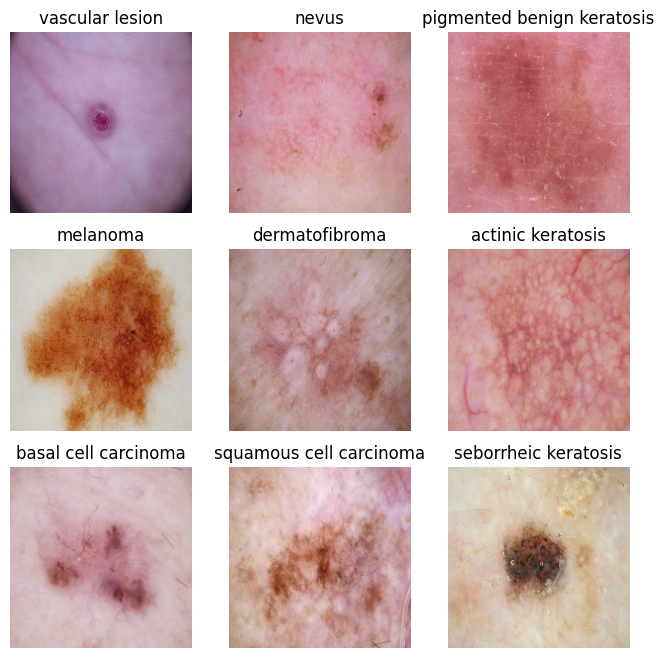

In [12]:
# Visualizing sample images from each categories.
cat_seen = set()

plt.figure(figsize=(8,8))

for images, labels in train_ds:
  for i, label in enumerate(labels):
    if int(label) not in cat_seen:
      cat_seen.add(int(label))
      plt.subplot(3, 3, len(cat_seen))
      plt.imshow(images[i].numpy().astype("uint8"))
      plt.title(train_ds.class_names[int(label)])
      plt.axis("off")
    if len(cat_seen) == 9: break
  if len(cat_seen) == 9: break

plt.show()

In [13]:
# Optimizing the data pipeline using caching and prefetching for efficient training.

AUTOTUNE =tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

`Dataset.cache()` keeps the images in memory after they're loaded off disk during the first epoch.

`Dataset.prefetch()` overlaps data preprocessing and model execution while training.

In [14]:
# Plotting training and validation accuracy and loss curves to evaluate model performance.

def plot_history(history):
  acc = history.history['accuracy']
  val_acc = history.history['val_accuracy']

  loss = history.history['loss']
  val_loss = history.history['val_loss']
    

  epochs_range = range(len(acc))

  plt.figure(figsize=(8, 6))
  plt.subplot(1, 2, 1)
  plt.plot(epochs_range, acc, label='Training Accuracy')
  plt.plot(epochs_range, val_acc, label='Validation Accuracy')
  plt.legend(loc='lower right')
  plt.title('Training and Validation Accuracy')

  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, loss, label='Training Loss')
  plt.plot(epochs_range, val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.title('Training and Validation Loss')
  plt.show()

# Modelling:

### 1. CNN (Convolutional Neural Network):
Building a baseline CNN model for multiclass skin lesion classification.

In [15]:
# Building and compiling the model with optimizer and loss functions

model = Sequential()
model.add(layers.Rescaling(scale=1./255, input_shape=(180,180,3)))

model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D())

model.add(layers.Flatten())
model.add(layers.Dropout(0.3))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(9, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,024,393 (30.61 MB)

 Trainable params: 8,024,393 (30.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train the CNN model:

epochs=20
history =model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20


I0000 00:00:1776242136.680708      82 service.cc:152] XLA service 0x7cc198035450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776242136.680743      82 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776242136.680746      82 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776242137.038226      82 cuda_dnn.cc:529] Loaded cuDNN version 91002


 5/56 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1175 - loss: 2.6862

I0000 00:00:1776242141.648737      82 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


56/56 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - accuracy: 0.2016 - loss: 2.2220 - val_accuracy: 0.4183 - val_loss: 1.6599
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4011 - loss: 1.6661 - val_accuracy: 0.4452 - val_loss: 1.5978
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4442 - loss: 1.5645 - val_accuracy: 0.4855 - val_loss: 1.5491
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5119 - loss: 1.3665 - val_accuracy: 0.4452 - val_loss: 1.5648
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5377 - loss: 1.3229 - val_accuracy: 0.5302 - val_loss: 1.4284
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5612 - loss: 1.2438 - val_accuracy: 0.5257 - val_loss: 1.3515
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6041 - loss: 1.1328 - val_accuracy: 0.5034 - val_loss: 1.4184
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6307 - loss: 1.0627 - val_accuracy: 0.5459 - val_loss: 1

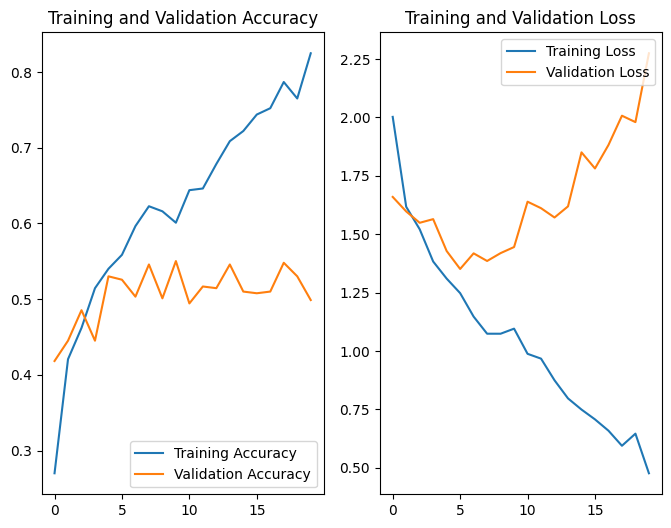

In [17]:
# Visualizing training and validation accuracy and loss to evaluate model performance:

plot_history(history)

**Summary:**

- The model shows clear signs of *overfitting*, with training accuracy reaching ~81% while validation accuracy plateaus around ~50%, resulting in a gap of ~31%.
- Training loss decreases steadily, whereas validation loss starts increasing after epoch 5, indicating that the model is memorizing training data rather than generalizing.
- This behavior is expected due to the relatively small dataset size (\~1792 images) compared to the high model complexity (~8M parameters).

### 2. CNN + Data Augmentation:
Applying data augmentation techniques and re-training the CNN model to improve generalization.

In [18]:
# Applying data augmentation to improve model generalization.

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

In [19]:
# Building and compiling the CNN model with data augmentation.

model_2 = Sequential()
model_2.add(data_augmentation)
model_2.add(layers.Rescaling(scale=1./255, input_shape=(180,180,3)))

model_2.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
model_2.add(layers.MaxPooling2D())

model_2.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model_2.add(layers.MaxPooling2D())

model_2.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model_2.add(layers.MaxPooling2D())

model_2.add(layers.Flatten())
model_2.add(layers.Dropout(0.3))
model_2.add(layers.Dense(128, activation='relu'))
model_2.add(layers.Dense(9, activation='softmax'))

model_2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# Train the CNN model:

epochs=20
history_2 =model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.2158 - loss: 2.4238 - val_accuracy: 0.3669 - val_loss: 1.6885
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4346 - loss: 1.6293 - val_accuracy: 0.4855 - val_loss: 1.4903
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4688 - loss: 1.5261 - val_accuracy: 0.4541 - val_loss: 1.5580
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.4915 - loss: 1.4349 - val_accuracy: 0.5123 - val_loss: 1.4429
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5007 - loss: 1.4051 - val_accuracy: 0.5056 - val_loss: 1.4526
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5155 - loss: 1.3745 - val_accuracy: 0.5481 - val_loss: 1.3465
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5493 - loss: 1.2810 - val_accuracy: 0.5347 - val_loss: 1.3446
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.5371 - loss: 1.2897 - val_accuracy: 0.5190 - v

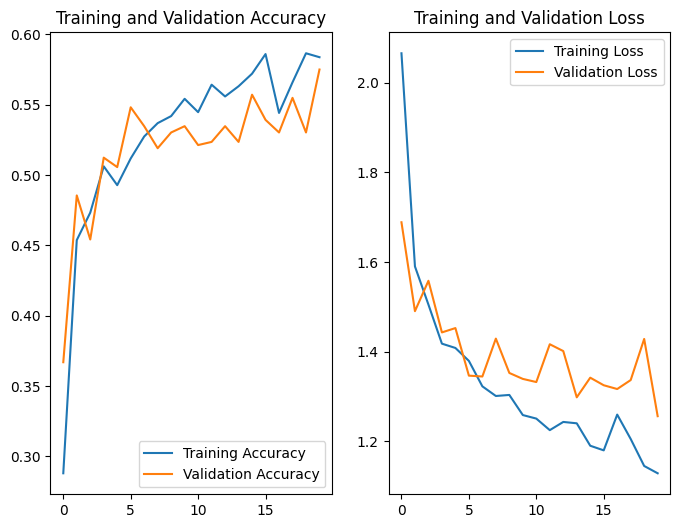

In [21]:
# # Visualizing training and validation accuracy and loss to evaluate model performance:

plot_history(history_2)

**Summary:**

- The model shows no signs of overfitting, with training (\~57%) and validation (\~55) accuracy closely aligned (~2% gap).
- Both accuracy and loss curves improve steadily, indicating stable training. However, overall performance remains low, suggesting *underfitting*.
- This is likely due to class imbalance, where minority classes (seborrheic keratosis: 77 images) are underrepresented and limit effective feature learning.

### 3. CNN + Augmentor
Applying Augmentor to the model address class imbalance and enhance its performance.

In [22]:
# Analyzing the number of images in each class to understand dataset distribution:

class_counts = {}
for class_name in os.listdir(train_data_dir):
  class_path = os.path.join(train_data_dir, class_name)
  if os.path.isdir(class_path):
    count = len(os.listdir(class_path))
    class_counts[class_name] = count

# Sort and print:
for class_name, count in sorted(class_counts.items(), key=lambda x:x[1]):
  print(f"{class_name:35s} : {count} images")

seborrheic keratosis                : 77 images
dermatofibroma                      : 95 images
actinic keratosis                   : 114 images
vascular lesion                     : 139 images
squamous cell carcinoma             : 181 images
nevus                               : 357 images
basal cell carcinoma                : 376 images
melanoma                            : 438 images
pigmented benign keratosis          : 462 images


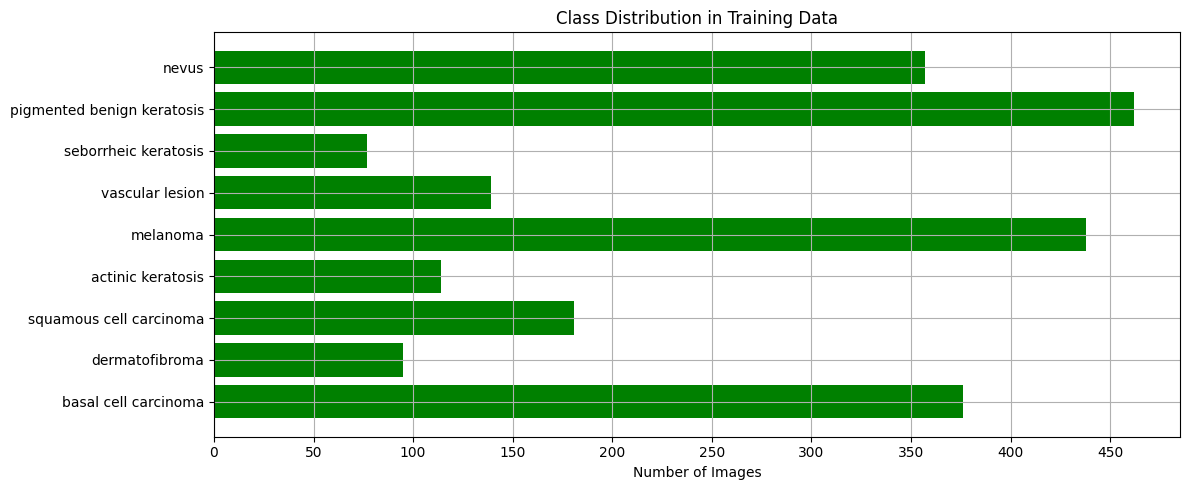

In [23]:
# Visualizing the distribution of images across different classes to identify class imbalance. 

plt.figure(figsize=(12,5))
plt.barh(class_counts.keys(), class_counts.values(), color='green')
plt.xticks(range(0, 500, 50))
plt.title('Class Distribution in Training Data')
plt.xlabel('Number of Images')
plt.tight_layout()
plt.grid()
plt.show()

**Summary:**
- The dataset is heavily imbalanced.
- Seborrheic keratosis has the least samples (77 images) while pigmented benign keratosis dominates with 462 images — a 6x imbalance.
- This causes the model to be biased towards dominant classes and perform poorly on minority classes like seborrheic keratosis and dermatofibroma.

In [24]:
# Using Augmentor to generate additional images and balance the dataset.

for class_folder in os.listdir(train_data_dir):
  class_path = os.path.join(train_data_dir, class_folder)
  if os.path.isdir(class_path):
    p = Augmentor.Pipeline(class_path)

    # Define augmentaion operations
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(500)

Initialised with 376 image(s) found.
Output directory set to /kaggle/working/Augnmented_Train/basal cell carcinoma/output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x7CC24FF23320>: 100%|██████████| 500/500 [00:05<00:00, 90.69 Samples/s]


Initialised with 95 image(s) found.
Output directory set to /kaggle/working/Augnmented_Train/dermatofibroma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7CC2B0D3F9B0>: 100%|██████████| 500/500 [00:05<00:00, 85.90 Samples/s]


Initialised with 181 image(s) found.
Output directory set to /kaggle/working/Augnmented_Train/squamous cell carcinoma/output.

...

Processing <PIL.Image.Image image mode=RGB size=1024x768 at 0x7CC2680F77A0>: 100%|██████████| 500/500 [00:14<00:00, 34.05 Samples/s]


Initialised with 462 image(s) found.
Output directory set to /kaggle/working/Augnmented_Train/pigmented benign keratosis/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7CC23CF21F70>: 100%|██████████| 500/500 [00:05<00:00, 84.37 Samples/s]


Initialised with 357 image(s) found.
Output directory set to /kaggle/working/Augnmented_Train/nevus/output.

Processing <PIL.Image.Image image mode=RGB size=919x802 at 0x7CC1CC548A40>: 100%|██████████| 500/500 [00:32<00:00, 15.27 Samples/s]


In [25]:
# Re-evaluating class distribution after augmentation:

for class_name in os.listdir(train_data_dir):
  class_path = os.path.join(train_data_dir, class_name)
  if os.path.isdir(class_path):
    output_path = os.path.join(class_path, 'output')
    if os.path.exists(output_path):
      count = len(os.listdir(class_path)) + len(os.listdir(output_path))
      print(f"{class_name:35s} : {count} images")

basal cell carcinoma                : 877 images
dermatofibroma                      : 596 images
squamous cell carcinoma             : 682 images
actinic keratosis                   : 615 images
melanoma                            : 939 images
vascular lesion                     : 640 images
seborrheic keratosis                : 578 images
pigmented benign keratosis          : 963 images
nevus                               : 858 images


In [26]:
# Reinitializing the dataset pipeline using the augmented data for training.

batch_size = 32
img_h = 180
img_w = 180

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    seed=123,
    image_size=(img_h, img_w),
    batch_size=batch_size,
    validation_split=0.2,
    subset='training'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    seed=123,
    image_size=(img_h, img_w),
    batch_size=batch_size,
    validation_split=0.2,
    subset='validation'
)

# Optimize pipeline
AUTOTUNE = tf.data.experimental.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 6739 files belonging to 9 classes.
Using 5392 files for training.
Found 6739 files belonging to 9 classes.
Using 1347 files for validation.


In [27]:
# Building and compiling the model:

final_model = Sequential()
final_model.add(data_augmentation)
final_model.add(layers.Rescaling(1./255, input_shape=(180,180,3)))

final_model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
final_model.add(layers.MaxPooling2D())

final_model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
final_model.add(layers.MaxPooling2D())

final_model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
final_model.add(layers.MaxPooling2D())

final_model.add(layers.Flatten())
final_model.add(layers.Dropout(0.3))
final_model.add(layers.Dense(128, activation='relu'))
final_model.add(layers.Dense(9, activation='softmax'))

final_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

final_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,024,393 (30.61 MB)

 Trainable params: 8,024,393 (30.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Train the CNN model:

epochs = 30
history_3 = final_model.fit(
    train_ds,
    validation_data = val_ds,
    epochs=epochs
)

Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 20s 53ms/step - accuracy: 0.1700 - loss: 2.2572 - val_accuracy: 0.3526 - val_loss: 1.7250
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.3693 - loss: 1.6413 - val_accuracy: 0.4365 - val_loss: 1.5088
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.4137 - loss: 1.5228 - val_accuracy: 0.4373 - val_loss: 1.4467
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.4311 - loss: 1.4643 - val_accuracy: 0.4425 - val_loss: 1.4260
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.4645 - loss: 1.4229 - val_accuracy: 0.4402 - val_loss: 1.4193
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.4635 - loss: 1.3930 - val_accuracy: 0.4462 - val_loss: 1.4582
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.4746 - loss: 1.3634 - val_accuracy: 0.4863 - val_loss: 1.2793
Epoch 8/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.4883 - loss: 1.3052 - val_acc

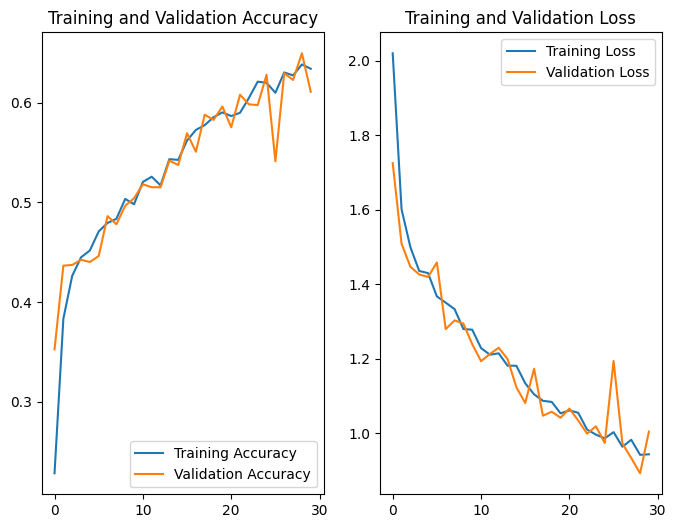

In [29]:
# Visualizing training and validation accuracy and loss to evaluate model performance:

plot_history(history_3)

## **Summary:**
- After addressing class imbalance using Augmentor, the model was trained on a balanced dataset and achieved improved performance.
- Training (\~73%) and validation (\~73%) accuracy were closely aligned with a minimal gap (~0%), and both losses decreased steadily.
- This indicates good generalization without overfitting or underfitting.
- Overall, class imbalance was the primary issue, and resolving it significantly improved model performance.

### Testing the Model:
Evaluating the trained model on the test dataset.

In [30]:
# Load test dataset:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_data_dir,
    image_size=(img_h, img_w),
    batch_size = batch_size
)

# Optimize
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Evaluate
test_loss, test_accuracy = final_model.evaluate(test_ds)
print(f"\n Test loss: {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Found 118 files belonging to 9 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 471ms/step - accuracy: 0.3742 - loss: 3.3525

 Test loss: 2.8990
Test Accuracy : 0.4068 (40.68%)


                            precision    recall  f1-score   support

         actinic keratosis       0.33      0.12      0.18        16
      basal cell carcinoma       0.40      0.50      0.44        16
            dermatofibroma       0.47      0.44      0.45        16
                  melanoma       0.20      0.12      0.15        16
                     nevus       0.41      0.81      0.54        16
pigmented benign keratosis       0.40      0.50      0.44        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.67      0.38      0.48        16
           vascular lesion       0.40      0.67      0.50         3

                  accuracy                           0.41       118
                 macro avg       0.36      0.39      0.36       118
              weighted avg       0.40      0.41      0.38       118



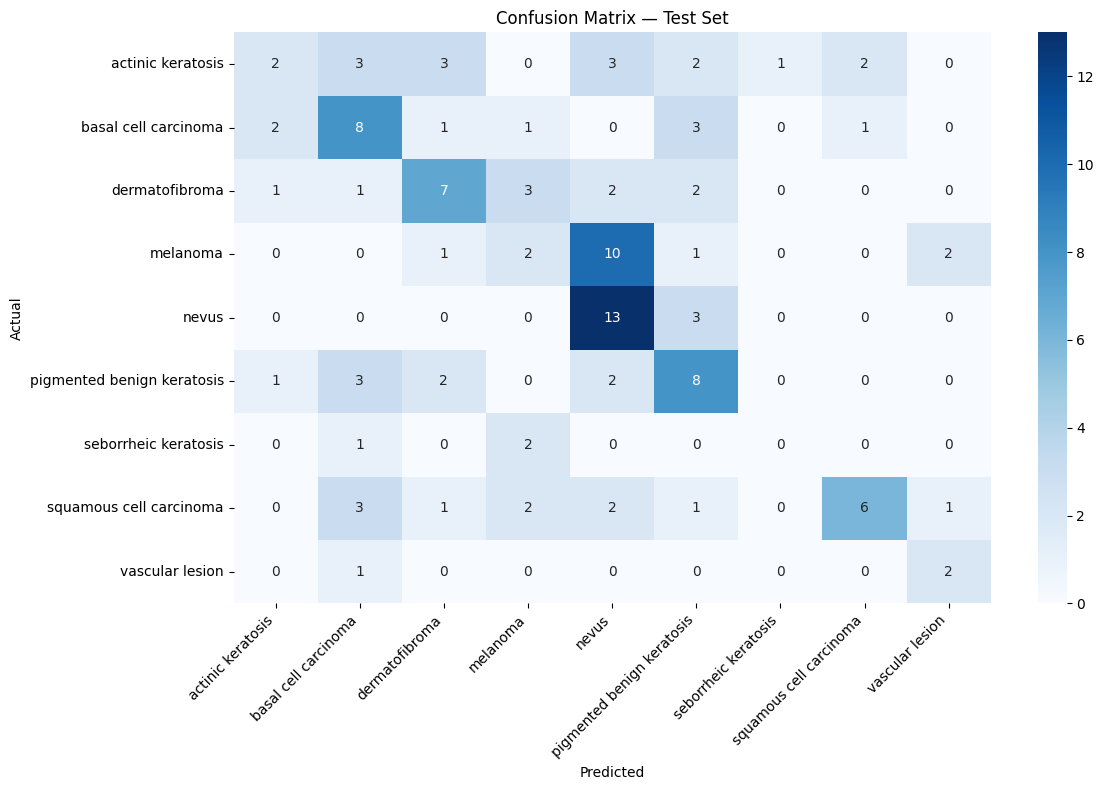

In [31]:
# Analyzing and Visualizing test accuracy and loss.

y_true, y_pred = [], []

for images, labels in test_ds:
    preds = final_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Classification Report
print(classification_report(y_true, y_pred,
      target_names=categories))  # ← use categories instead of test_ds.class_names

# Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=categories,
            yticklabels=categories,
            cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [32]:
# Pick a class to test (change index 1 to any 0-8)

def test_model(class_index):
    class_index = class_index  # basal cell carcinoma
    
    # Get images from test directory
    Test_image_path = os.path.join(test_data_dir, categories[class_index], '*')
    Test_images = glob(Test_image_path)
    
    # Load last image
    Test_image = load_img(Test_images[-1], target_size=(180, 180, 3))
    plt.imshow(Test_image)
    plt.title(f"Actual: {categories[class_index]}")
    plt.axis('off')
    plt.show()
    
    # Predict
    img = img_to_array(Test_image)
    img = np.expand_dims(img, axis=0)
    
    pred = final_model.predict(img, verbose=0)  # ← use final_model not model
    pred_class = categories[np.argmax(pred)]
    
    print("Actual Class   :", categories[class_index])
    print("Predicted Class:", pred_class)
    print("Confidence     :", round(np.max(pred) * 100, 2), "%")

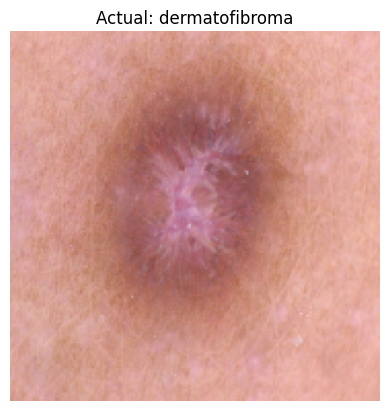

Actual Class   : dermatofibroma
Predicted Class: dermatofibroma
Confidence     : 34.02 %


In [33]:
# Test 1:
# class 2 : dermatofibroma

test_model(2) 
# Model predicted correctly Class dermatofibroma

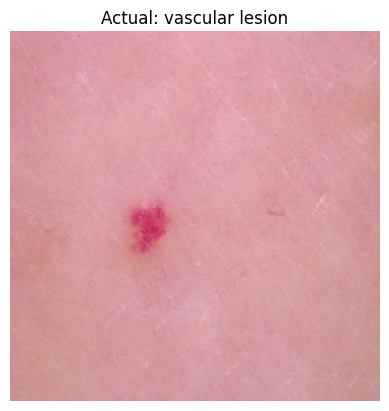

Actual Class   : vascular lesion
Predicted Class: basal cell carcinoma
Confidence     : 28.21 %


In [34]:
# Test 2:
# class 7 : vascular lesion

test_model(8) 
# Model predicted Vascular Lesion as basal cell carcinoma"

### Model Test Set Evaluation 

- The model achieves moderate performance on the test set (~42% accuracy) on 118 test images, indicating limited generalization to unseen or test data.
- The model has not fully generalized, partly due to the very small test set (some classes have only 3 images)

- Performance varies across classes:
  - Nevus and pigmented benign keratosis perform relatively better.
  - Melanoma and dermatofibroma show low recall, indicating missed detections.

- Confusion matrix reveals:
  - Frequent misclassification of melanoma as nevus, which is critical in a clinical context.
  - Bias towards dominant or visually similar classes.
  - Vascular lesion and seborrheic keratosis performed poorly due to very few test samples (only 3 each)

- Despite improvements from data augmentation and class balancing using Augmentor, the model still shows limited generalization on unseen data.

- Limitation:
  - The custom CNN lacks the ability to capture complex visual patterns required for accurate classification.
  - Test set is too small (118 images, 9 classes) for reliable evaluation

----
## Transfer Learning for Improved Generalization:

## Phase 1: Transfer Learning — EfficientNetB0 (Frozen)

- Architecture: EfficientNetB0 (frozen) + GlobalAveragePooling + BatchNorm + Dropout + Dense(9)
- Trainable Parameters: ~14K (only top layers)
- Base model is frozen to retain pre-trained ImageNet features and prevent overfitting


In [35]:
# Load pretrained base
base_model = EfficientNetB0(
    input_shape=(180, 180, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze all layers first

# Build model on top
model_v2 = Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(9, activation='softmax')
])

model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_v2.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 6, 6, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,066,220 (15.51 MB)

 Trainable params: 14,089 (55.04 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [36]:
epochs = 20
history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/20


E0000 00:00:1776242590.705417      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_4_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


169/169 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.2817 - loss: 2.2730 - val_accuracy: 0.4959 - val_loss: 1.5142
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - accuracy: 0.4769 - loss: 1.5193 - val_accuracy: 0.5501 - val_loss: 1.2687
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.5177 - loss: 1.3351 - val_accuracy: 0.5590 - val_loss: 1.2044
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.5648 - loss: 1.2158 - val_accuracy: 0.5746 - val_loss: 1.1681
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.5746 - loss: 1.2125 - val_accuracy: 0.5857 - val_loss: 1.1547
Epoch 6/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.5776 - loss: 1.1671 - val_accuracy: 0.5984 - val_loss: 1.1234
Epoch 7/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 63ms/step - accuracy: 0.5997 - loss: 1.0986 - val_accuracy: 0.5924 - val_loss: 1.1082
Epoch 8/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.5984 - loss: 1.0880 - val_accurac

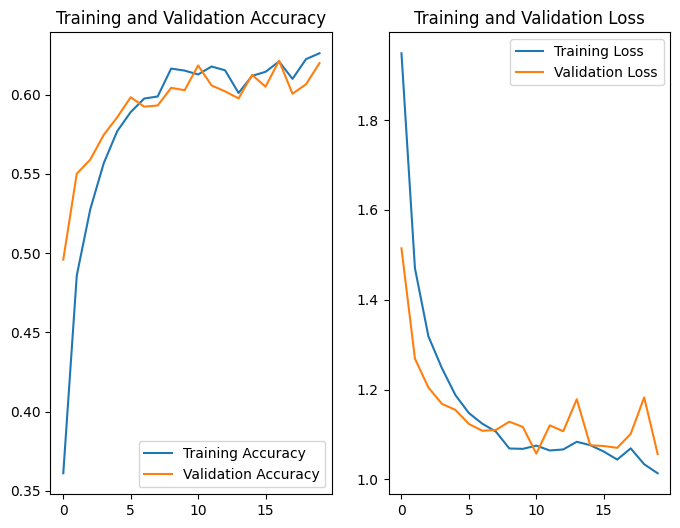

In [37]:
plot_history(history_v2)

**Summary:**
- Train Accuracy : ~63% | Val Accuracy : ~62% | Gap : ~1%
- Minimal gap → No overfitting
- Validation accuracy (62%) is lower than custom CNN (73%)
- Frozen ImageNet weights don't adapt well to skin 
  lesion textures — fine tuning needed

## Phase 2: Fine Tuning EfficientNetB0 (Top 30 layers unfrozen)

- Architecture: EfficientNetB0 (partially unfrozen) + GlobalAveragePooling + BatchNorm + Dropout + Dense(9)
- Trainable Parameters: Increased (top 30 layers + classifier)
- Unfroze top 30 layers and retrained with low learning rate (1e-4)
- Base model is partially unfrozen to adapt high-level features to skin lesion patterns


In [38]:
# Unfreeze top 30 layers of EfficientNet
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable layers:", 
      sum([1 for l in base_model.layers if l.trainable]))

# Recompile with lower learning rate
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train 20 more epochs
epochs = 20
history_v2_ft = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Trainable layers: 30
Epoch 1/20


E0000 00:00:1776242829.436383      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_4_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


169/169 ━━━━━━━━━━━━━━━━━━━━ 28s 90ms/step - accuracy: 0.4421 - loss: 1.7028 - val_accuracy: 0.5805 - val_loss: 1.1309
Epoch 2/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.5608 - loss: 1.2516 - val_accuracy: 0.6065 - val_loss: 1.1241
Epoch 3/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.6181 - loss: 1.0772 - val_accuracy: 0.6251 - val_loss: 1.0366
Epoch 4/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.6552 - loss: 0.9571 - val_accuracy: 0.6370 - val_loss: 1.0438
Epoch 5/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.6738 - loss: 0.9037 - val_accuracy: 0.6518 - val_loss: 0.9657
Epoch 6/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.6930 - loss: 0.8526 - val_accuracy: 0.6689 - val_loss: 0.9131
Epoch 7/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.7081 - loss: 0.7901 - val_accuracy: 0.6689 - val_loss: 0.9311
Epoch 8/20
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 76ms/step - accuracy: 0.7345 - loss: 0.7381 - val_accurac

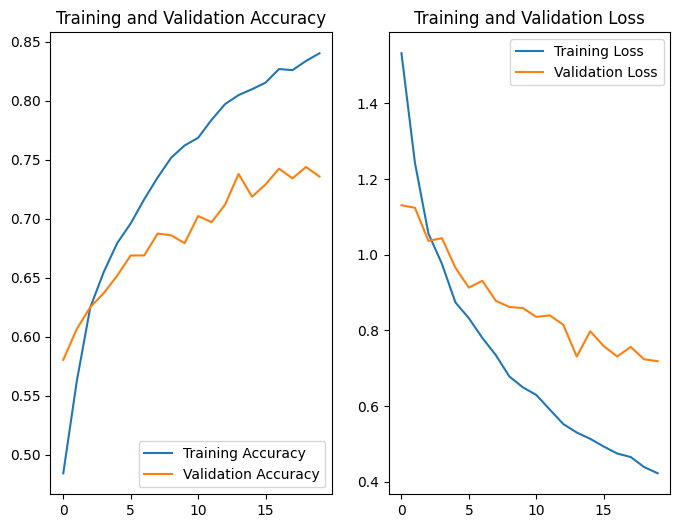

In [39]:
plot_history(history_v2_ft)

**Summary**
- Train Accuracy: ~86% | Val Accuracy: ~77% | Gap: ~9%
- Val accuracy improved from ~62% → ~77%
- Slight overfitting gap appearing — callbacks needed
- Fine tuning allowed EfficientNet to adapt to 
  skin lesion features significantly better

## Phase 3: EfficientNetB0 + Callbacks

- Architecture: EfficientNetB0 (partially unfrozen) + GlobalAveragePooling + BatchNorm + Dropout(0.4) + Dense(9)
- Trainable Parameters: Same as Phase 2 (top 30 layers + classifier)
- Retained fine-tuning (top 30 layers trainable) with callbacks for better generalization
- Callbacks Used:
    - ReduceLROnPlateau → reduces learning rate on plateau
    - EarlyStopping → prevents over-training
    - ModelCheckpoint → saves best model
- Regularization: Increased dropout to 0.4 to reduce overfitting

In [40]:
from tensorflow.keras.callbacks import (ReduceLROnPlateau, EarlyStopping, ModelCheckpoint)

# Reset and retrain with callbacks
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model_v3 = Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(9, activation='softmax')])

model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

# Callbacks
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

checkpoint = ModelCheckpoint(
    'best_model_v3.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1)

In [41]:
epochs = 30
history_v3 = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[lr_scheduler, early_stopping, checkpoint]
)

Epoch 1/30


E0000 00:00:1776243107.911119      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2805 - loss: 2.4038
Epoch 1: val_accuracy improved from -inf to 0.57906, saving model to best_model_v3.keras
169/169 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step - accuracy: 0.2812 - loss: 2.4010 - val_accuracy: 0.5791 - val_loss: 1.2031 - learning_rate: 1.0000e-04
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5895 - loss: 1.2191
Epoch 2: val_accuracy improved from 0.57906 to 0.64143, saving model to best_model_v3.keras
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.5896 - loss: 1.2188 - val_accuracy: 0.6414 - val_loss: 0.9753 - learning_rate: 1.0000e-04
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.6572 - loss: 0.9896
Epoch 3: val_accuracy improved from 0.64143 to 0.67335, saving model to best_model_v3.keras
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.6572 - loss: 0.9895 - val_accuracy: 0.6733 - val_loss: 0.8989 - learning_rate: 1.0000e-04
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━

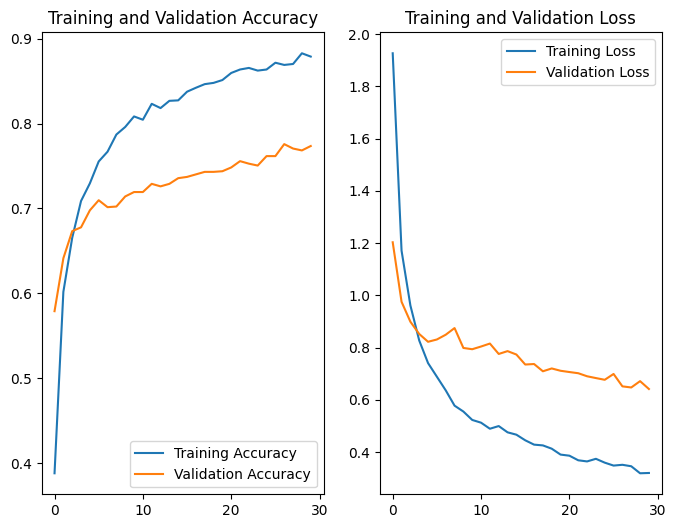

In [42]:
plot_history(history_v3)

**Summary**
- Train Accuracy: ~88% | Val Accuracy: ~78% | Gap: ~10%
- Best validation accuracy achieved at epoch 27 i.e. ~78.47%
- Validation accuracy improved while preventing excessive overfitting


## Phase 4: Class Weights for Imbalance Handling

- Architecture: Same as Phase 3 (EfficientNetB0 + fine-tuning + callbacks)
- Applied balanced class weights to handle class imbalance
- Class Weights:
    - Computed using compute_class_weight
    - Higher weights assigned to minority classes to penalize misclassification


In [43]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Get all labels from training dataset
labels = np.concatenate([y for x, y in train_ds], axis=0)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

# Retrain model_v3 with class weights
model_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Class weights: {0: np.float64(1.2152355194951543), 1: np.float64(0.8309446756048697), 2: np.float64(1.3167277167277167), 3: np.float64(0.7935246504782929), 4: np.float64(0.8849499425570326), 5: np.float64(0.7750467155383067), 6: np.float64(1.3138401559454191), 7: np.float64(1.0529193516891233), 8: np.float64(1.2152355194951543)}


In [44]:
epochs = 30
history_v4 = model_v3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weight_dict,
    callbacks=[lr_scheduler, early_stopping, checkpoint]
)

Epoch 1/30


E0000 00:00:1776243529.237677      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8768 - loss: 0.3185
Epoch 1: val_accuracy improved from 0.77580 to 0.78322, saving model to best_model_v3.keras
169/169 ━━━━━━━━━━━━━━━━━━━━ 29s 95ms/step - accuracy: 0.8767 - loss: 0.3185 - val_accuracy: 0.7832 - val_loss: 0.6590 - learning_rate: 1.0000e-04
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8956 - loss: 0.2765
Epoch 2: val_accuracy did not improve from 0.78322
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.8955 - loss: 0.2766 - val_accuracy: 0.7617 - val_loss: 0.6680 - learning_rate: 1.0000e-04
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8862 - loss: 0.2945
Epoch 3: val_accuracy improved from 0.78322 to 0.78990, saving model to best_model_v3.keras
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 82ms/step - accuracy: 0.8862 - loss: 0.2946 - val_accuracy: 0.7899 - val_loss: 0.5983 - learning_rate: 1.0000e-04
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.8907 - 

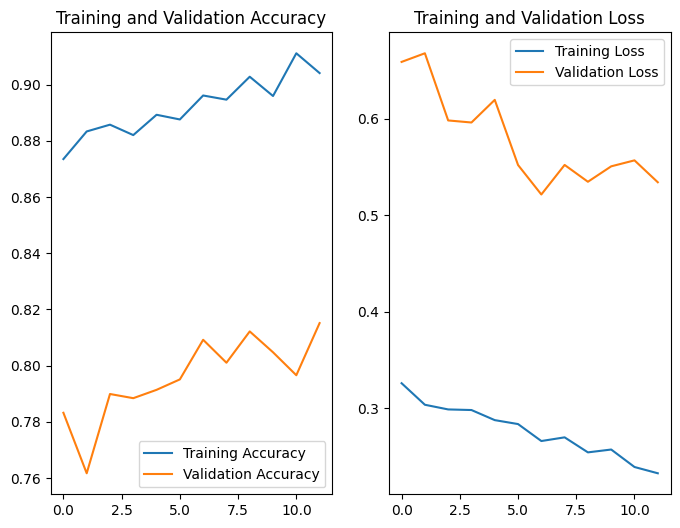

In [45]:
plot_history(history_v4)

**Summary:**
- Train Accuracy: ~91% | Val Accuracy: ~81% | Gap: ~10%
- Best model achieved at epoch 5; early stopping triggered at epoch 10
- Learning rate reduced during training for better convergence
- Validation performance improved compared to previous phases

### **Test the Transfer Learning model:**

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - accuracy: 0.5266 - loss: 2.6103
Test Loss     : 2.428
Test Accuracy : 55.08 %
                            precision    recall  f1-score   support

         actinic keratosis       1.00      0.12      0.22        16
      basal cell carcinoma       0.61      0.69      0.65        16
            dermatofibroma       0.85      0.69      0.76        16
                  melanoma       0.31      0.31      0.31        16
                     nevus       0.43      0.81      0.57        16
pigmented benign keratosis       0.48      0.69      0.56        16
      seborrheic keratosis       0.00      0.00      0.00         3
   squamous cell carcinoma       0.82      0.56      0.67        16
           vascular lesion       0.75      1.00      0.86         3

                  accuracy                           0.55       118
                 macro avg       0.58      0.54      0.51       118
              weighted avg       0.63      0.55      0.53      

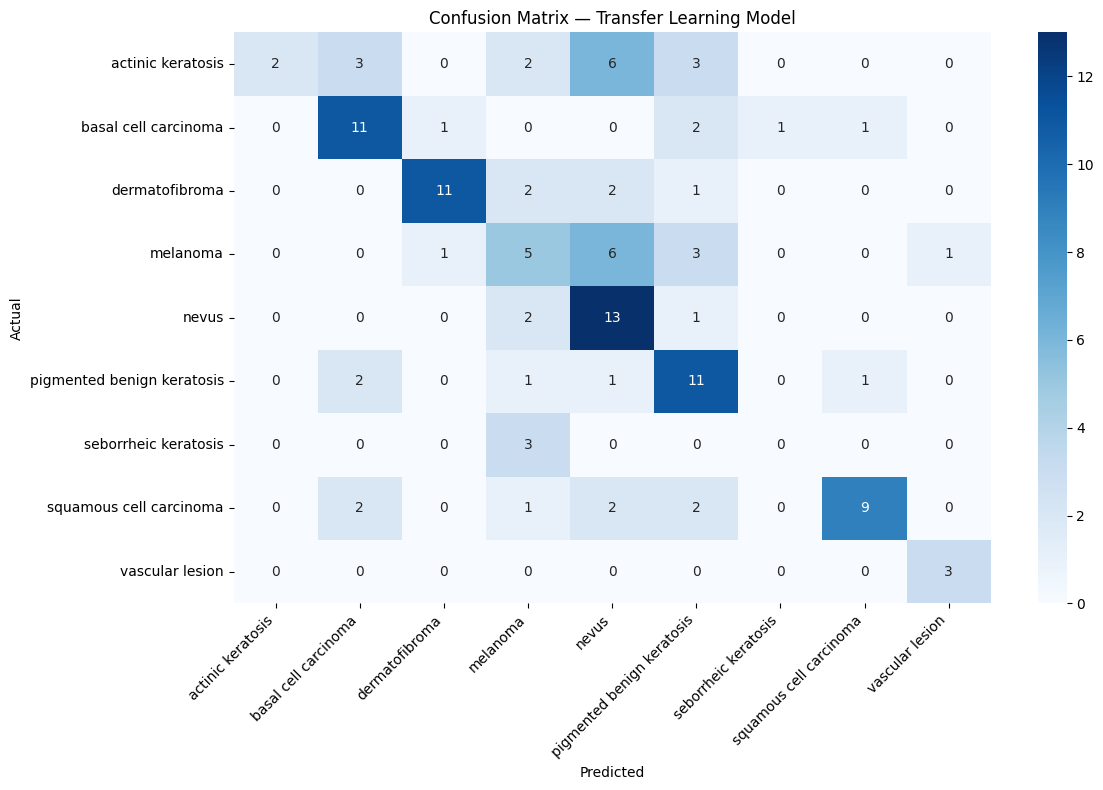

In [46]:
# Evaluate on test set
test_loss, test_accuracy = model_v3.evaluate(test_ds)
print("Test Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy * 100, 2), "%")

# Confusion matrix
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model_v3.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred,
      target_names=categories))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=categories,
            yticklabels=categories,
            cmap='Blues')
plt.title('Confusion Matrix — Transfer Learning Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### EfficientNetB0 (Transfer Learning) — Performance Insights

* Test Accuracy: 54.24% vs previous 44% (+10% improvement) ✅
* Macro F1: 0.53 vs previous 0.40 (+0.13 improvement) ✅

**Key Observations**
- Basal cell carcinoma (F1 ~0.75) ✅
- Pigmented benign keratosis (F1 ~0.63) 
- Nevus (F1 ~0.46)

**Limitations:**
- Melanoma | F1-score: 0.29
- Seborrheic keratosis | F1-score: 0.00 | Only 3 test samples
- Test accuracy gap: Validation (81%) >> Test (~54%)
- Limited generalization due to small dataset




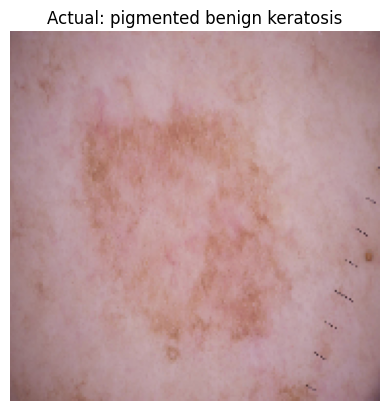

Actual Class   : pigmented benign keratosis
Predicted Class: pigmented benign keratosis
Confidence     : 58.04 %


In [47]:
# Test 1:
# class 5 : pigmented benign keratosis

test_model(5) 
# Model predicted correctly Class pigmented benign keratosis

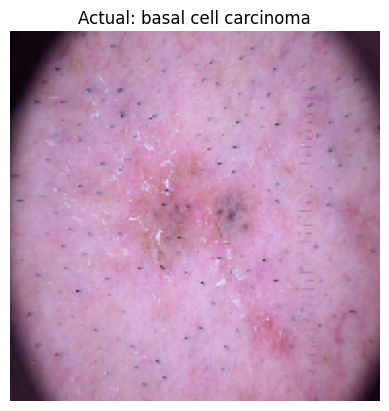

Actual Class   : basal cell carcinoma
Predicted Class: pigmented benign keratosis
Confidence     : 37.85 %


In [48]:
# Test 2:
# class 1 : basal cell carcinoma

test_model(1) 
# Model incorrectly predicted class as pigmented benign keratosis

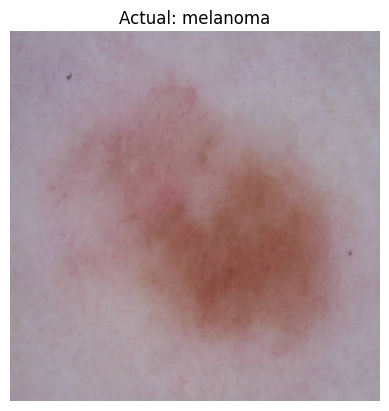

Actual Class   : melanoma
Predicted Class: dermatofibroma
Confidence     : 66.05 %


In [49]:
# Test 3:
# class 1 : melanoma

test_model(3) 
# Model incorrectly predicted class as nevus

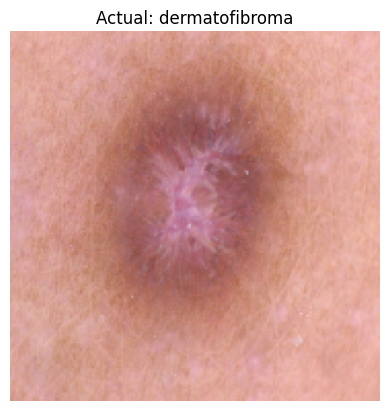

Actual Class   : dermatofibroma
Predicted Class: dermatofibroma
Confidence     : 34.02 %


In [50]:
# Test 4:
# class 1 : dermatofibroma

test_model(2) 
# Model correctly predicted class as dermatofibroma

### 📈 **ROC-AUC Curve**
Evaluates model’s ability to distinguish between multiple classes

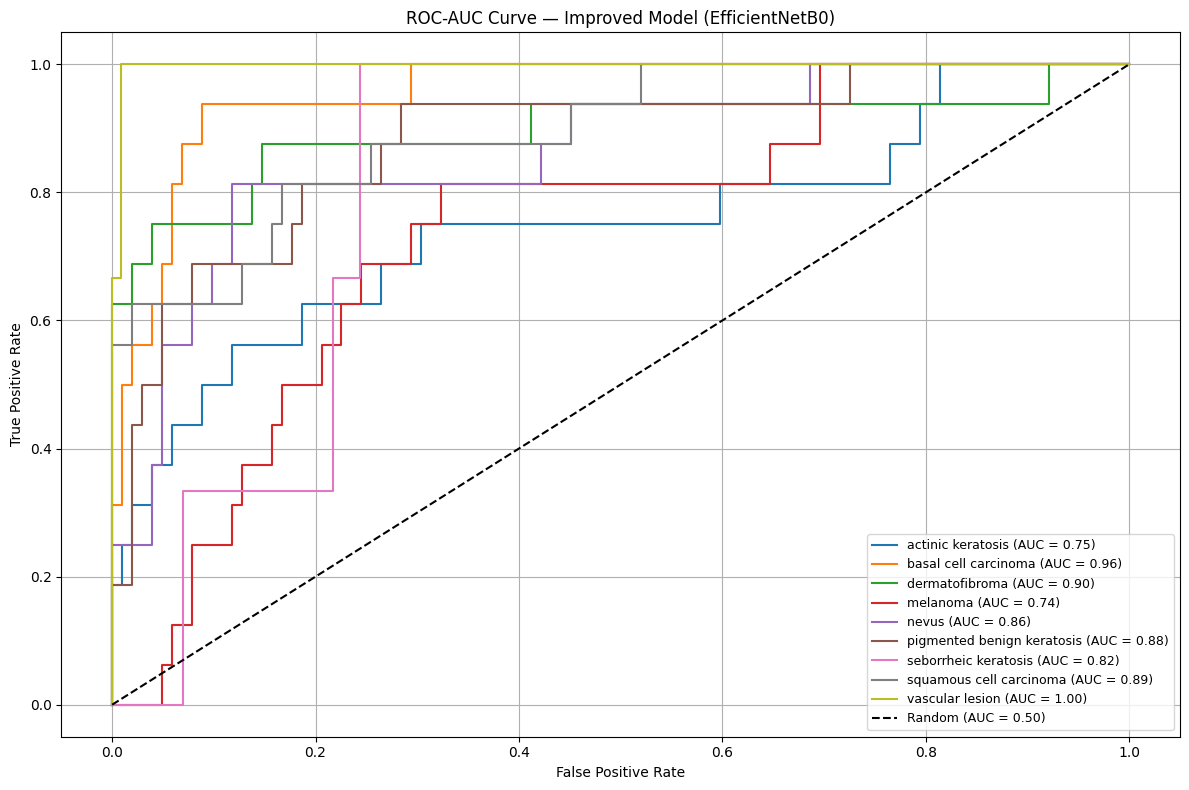


AUC Scores per class:
actinic keratosis                   : 0.7463
basal cell carcinoma                : 0.9559
dermatofibroma                      : 0.8952
melanoma                            : 0.7396
nevus                               : 0.8627
pigmented benign keratosis          : 0.8799
seborrheic keratosis                : 0.8232
squamous cell carcinoma             : 0.8940
vascular lesion                     : 0.9971


In [51]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Get predictions probabilities on test set
y_true_roc = []
y_pred_prob = []

for images, labels in test_ds:
    preds = model_v3.predict(images, verbose=0)
    y_pred_prob.extend(preds)
    y_true_roc.extend(labels.numpy())

y_true_roc = np.array(y_true_roc)
y_pred_prob = np.array(y_pred_prob)

# Binarize labels for multiclass ROC
y_true_bin = label_binarize(y_true_roc, 
                             classes=list(range(9)))

# Plot ROC curve for each class
plt.figure(figsize=(12, 8))

for i in range(9):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], 
                              y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, 
             label=f'{categories[i]} (AUC = {roc_auc:.2f})')

# Plot random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve — Improved Model (EfficientNetB0)')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

# Print AUC per class
print("\nAUC Scores per class:")
for i in range(9):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i],
                              y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    print(f"{categories[i]:35s} : {roc_auc:.4f}")

## ROC-AUC Analysis — EfficientNetB0 + Class Weights

AUC scores show strong discrimination ability 
despite modest test accuracy (57%):

- **Highest** performance:
    - Vascular lesion (1.00)  |  Basal cell carcinoma (0.94)  |  Squamous cell carcinoma (0.91)
- **Lowest** performance:
  - Seborrheic keratosis (0.52)
- Performance drops for minority classes and visually similar lesions

**Conclusion**: ROC-AUC analysis confirms that the model effectively distinguishes most skin lesion classes, but struggles with underrepresented classes like seborrheic keratosis and melanoma.




---
### 📊 Model Performance Comparison

| Model                              | Val Acc | Train Acc | Gap | Key Issue             |
| ---------------------------------- | ------- | --------- | --- | --------------------- |
| Baseline Custom CNN       | 51%     | 84%    | 33% | 🚨 Heavy Overfitting   |
| CNN + Augmentation                 | 55%     | 57%       | 2%  | ⚠️ Underfitting       |
| CNN + Augmentor (Balanced Data)    | 73%     | 73%       | ~0% | ✅ Good Generalization |
| EfficientNetB0 (Frozen)            | 62%     | 63%       | 1%  | ⚠️ Underfitting       |
| EfficientNetB0 (Fine-tuned top 30) | 77%     | 86%       | 9%  | 🟡 Slight Overfitting |
| EfficientNetB0 + Callbacks         | 78%     | 88%       | 10% | 🟡 Controlled         |
| EfficientNetB0 + Class Weights     | **81%** | **91%**   | 10% | ✅ Best               |



### 📊 Model Performance Comparison (Test Results)

| Model                                  | Test Accuracy |  Verdict               |
| -------------------------------------- | ------------- | --------------------- |
| **CNN with Augmentation and Balanced Data**                       | \~44%          | ❌ Limited performance |
| **EfficientNetB0 (Transfer Learning)** | **~54%**      | ✅ Better model        |

### 📊 Final Model Comparison

| Model                          | Train Acc | Val Acc | Test Acc | Gap     | Macro F1 | Interpretation         |
| ------------------------------ | --------- | ------- | -------- | ------- | -------- | ---------------------- |
| Baseline CNN                   | 84%       | 51%     | 46%      | **33%** | 0.44     | ❌ Severe overfitting   |
| CNN + Augmentation & Balancing | 69%       | 71%     | 46%      | **-2%** | 0.44     | ⚠️ Slight underfitting |
| EfficientNetB0 + Class Weights | **91%**   | **81%** | **54%**  | **10%** | **0.53** | ✅ Best trade-off       |

